In [348]:
import polars as pl
import numpy as np
import plotly.express as px
import torch
import torch.nn as nn
from matplotlib.pyplot import title
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [349]:
nPerClust = 300
blur = 1

A = [1, 1]
B = [5, 1]
C = [4, 4]

# Generate data using Polars
# Create DataFrames for each cluster
a_df = pl.DataFrame({
    'x': A[0] + np.random.randn(nPerClust) * blur,
    'y': A[1] + np.random.randn(nPerClust) * blur,
    'label': [0] * nPerClust
})

b_df = pl.DataFrame({
    'x': B[0] + np.random.randn(nPerClust) * blur,
    'y': B[1] + np.random.randn(nPerClust) * blur,
    'label': [1] * nPerClust
})

c_df = pl.DataFrame({
    'x': C[0] + np.random.randn(nPerClust) * blur,
    'y': C[1] + np.random.randn(nPerClust) * blur,
    'label': [2] * nPerClust
})

# Concatenate into a single DataFrame
all_data = pl.concat([a_df, b_df, c_df])

In [350]:
print(all_data)

shape: (900, 3)
┌───────────┬──────────┬───────┐
│ x         ┆ y        ┆ label │
│ ---       ┆ ---      ┆ ---   │
│ f64       ┆ f64      ┆ i64   │
╞═══════════╪══════════╪═══════╡
│ -1.22035  ┆ 0.827746 ┆ 0     │
│ 0.789716  ┆ 1.465726 ┆ 0     │
│ 0.398347  ┆ 1.324297 ┆ 0     │
│ -0.074343 ┆ 1.421686 ┆ 0     │
│ 1.636824  ┆ 1.555126 ┆ 0     │
│ …         ┆ …        ┆ …     │
│ 3.552611  ┆ 3.657531 ┆ 2     │
│ 3.020766  ┆ 2.962437 ┆ 2     │
│ 4.833295  ┆ 5.273351 ┆ 2     │
│ 4.583766  ┆ 2.569564 ┆ 2     │
│ 3.651225  ┆ 3.808302 ┆ 2     │
└───────────┴──────────┴───────┘


In [351]:
# get the features
features = all_data.select(pl.exclude('label')).to_numpy()
label = all_data.select(pl.col('label')).to_numpy().squeeze()

# convert to torch tensor
featuresT = torch.tensor(features, dtype=torch.float32)
labelT = torch.tensor(label, dtype=torch.int64)

# compute the Euclidean distance tot he origin
euclidean_distance = torch.sqrt(featuresT[:, 0]**2 + featuresT[:, 1]**2)

# add the euclidea_distance back to the feature
dataAugT = torch.column_stack([featuresT, euclidean_distance])

In [352]:
px.box(
    data_frame=dataAugT,
    points='all'
)

In [353]:
# use scikitlearn to split the data
X_train, X_test, y_train, y_test = train_test_split(dataAugT, labelT, test_size=0.2, random_state=42)

# convert to tensordatase
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# tranlsate into dataloader object
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

## Create a class for the model

In [354]:
class ANNmodel(nn.Module):
  def __init__(self, nUnits, nLayers, useExtraFeature=False):
    super().__init__()

    # Store the parameter as an instance attribute
    self.useExtraFeature = useExtraFeature

    # create a dictionary to store the layers
    self.layers = nn.ModuleDict()

    if useExtraFeature: # if we choose to use extra feature then make the input as 3 else 2
      # input layers
      self.layers['input'] = nn.Linear(3, nUnits)
    else:
      self.layers['input'] = nn.Linear(2, nUnits)

    # generate the hidden layers
    for i in range(nLayers):
      self.layers[f'hidden{i}'] = nn.Linear(nUnits, nUnits)

    # output layer
    self.layers['output'] = nn.Linear(nUnits, 3)

  def forward(self, x):

    if not self.useExtraFeature: # Now referencing the instance attribute
      x = x[:, :2]
      # print(f'Shape of the features used {x.shape}')

    x = F.relu(self.layers['input'](x))

    # hidden layers
    for i in range(len(self.layers) - 2): # minus the input and output layers
      x = F.relu(self.layers[f'hidden{i}'](x))

    # return output layer
    x = self.layers['output'](x)
    return x

In [355]:
# test the model
X = torch.randn(100, 3)

model = ANNmodel(nUnits=3, nLayers=2, useExtraFeature=False)

output = model(X)
print(f"Input shape: {X.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([100, 3])
Output shape: torch.Size([100, 3])


In [356]:
# create the components
def createANNnet(train_loader, test_loader, nUnits, nLayers, useExtraFeature=False, learningRate=0.01, epochStep=10, gamma=1):
  model  = ANNmodel(nUnits, nLayers, useExtraFeature)
  lossfunc = nn.CrossEntropyLoss( )
  optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)

  step_size = len(test_loader) * epochStep
  scheduler = torch.optim.lr_scheduler.StepLR(
      optimizer, step_size=step_size, gamma=gamma
  )
  return model, lossfunc, optimizer, scheduler

In [357]:
len(test_loader)

1

In [358]:
# function to trian the model
import copy

def trainModel(train_loader, test_loader, nUnits, nLayers, numepochs=500, toggleDynamic=False, useExtraFeature=False):
  # create the dataframe
  training_progress = pl.DataFrame(
      schema=[
            ('iteration', pl.Int64),
            ('epoch', pl.Int64),
            ('train_loss', pl.Float64),
            ('train_acc', pl.Float64),
            ('test_loss', pl.Float64),
            ('test_acc', pl.Float64),
            ('learning_rate', pl.Float64)
        ]
    )
  iteration = 0

  # create the ANN model
  model, lossfunc, optimizer, scheduler = createANNnet(
      train_loader, test_loader, nUnits, nLayers, learningRate=0.01, epochStep=10, gamma=1
  )

  # load the test loader
  X_testTL, y_testTL = next(iter(test_loader))

  # setting the early stop parameters
  patience = 100
  best_loss = float('inf')
  no_improvement_count = 0
  best_model = None

  # training loop
  for epoch in range(numepochs): # Changed to range(numepochs)
    model.train()

    epoch_train_loss = 0
    epoch_train_acc = 0
    num_batches = 0

    # iterate through the training batches
    for X_trainTL, y_trainTL in train_loader:
      yhat_train = model(X_trainTL)
      train_loss = lossfunc(yhat_train.squeeze(), y_trainTL)

      optimizer.zero_grad()
      train_loss.backward()
      optimizer.step()

      # evalutea the training accurarcy
      train_matches = (torch.argmax(yhat_train, axis=1) == y_trainTL).float()
      train_acc = 100 * torch.mean(train_matches)

      # sum the loss and accuracy
      epoch_train_loss += train_loss.item()
      epoch_train_acc += train_acc.item()
      num_batches += 1

    # update the learning rate after all batches (once per epoch)
    if toggleDynamic:
      scheduler.step()
      current_lrs = scheduler.get_last_lr()[0]

    else:
      current_lrs = optimizer.param_groups[0]['lr']

    # end of epoch: evaluate test once
    model.eval()
    with torch.no_grad(): # Added colon
      yhat_test = model(X_testTL)
      test_loss = lossfunc(yhat_test.squeeze(), y_testTL)

      # get the test accuracy
      test_matches = (torch.argmax(yhat_test, axis=1) == y_testTL).float()
      test_acc = (100*torch.mean(test_matches))

    # log a single row per epoch
    new_row = pl.DataFrame([{
        'iteration': iteration,
        'epoch': epoch,
        'train_loss': epoch_train_loss / num_batches,
        'train_acc': epoch_train_acc / num_batches,
        'test_loss': test_loss.item(),
        'test_acc': test_acc.item(),
        'learning_rate': current_lrs
    }])

    training_progress = training_progress.vstack(new_row)
    iteration += 1

    # early stopping if the model does not improve after patience counts
    if test_loss < best_loss:
      best_loss = test_loss.item() # update the best model when model improves
      no_improvement_count = 0 # reset the counter to 0
      best_copy = copy.deepcopy(model)

    else:
      no_improvement_count += 1
      if no_improvement_count >= patience:
        print(f'Stopping at {epoch +1} - No improvement for {patience} epochs')
        break

    # print out the performance afer every 10 epochs
    if epoch % 10 == 0 or epoch == numepochs -1:
      print(
            f"Epoch {epoch+1}/{numepochs} - "
            f"Training: Loss={epoch_train_loss / num_batches:.4f}, "
            f"Accuracy={epoch_train_acc / num_batches:.2f}% | "
            f"Testing: Loss={test_loss.item():.4f}, "
            f"Accuracy={test_acc.item():.2f}% | "
            f"Learning Rate: {current_lrs:.6f}"
            )

  # return both training model progress and best model
  return training_progress, best_model if best_model is not None else model # Moved return statement outside the loop

In [359]:
# quickly test if the loop is working
# training_progress, trained_model = trainModel(train_loader=train_loader, test_loader=test_loader, nUnits=64, nLayers=2, numepochs=500, toggleDynamic=False)

In [360]:

# running the experiment
# define the hyperparameters
nUnits = 8
nLayers = 1

bool_order = [False, True]

# a list to store the dataframe
training_results = []
class_acc = []

for idx, boolean in enumerate(bool_order):
  print(f'Training with useExtraFeature={boolean}')
  # training the model
  training_progress, trained_model = trainModel(train_loader, test_loader, nUnits, nLayers, numepochs=200,toggleDynamic=False, useExtraFeature=boolean) # previously I forgottent change the useExtraFeature to boolean
  # add a new column
  training_progress = training_progress.with_columns(extraFeature=pl.lit(boolean))
  # append to the list
  training_results.append(training_progress)

  # compute per class accuracy
  trained_model.eval()
  with torch.no_grad():
    X, y = next(iter(test_loader))
    # get predictions
    yhat = trained_model(X)
    predictions = torch.argmax(yhat, dim=1) # specify the dimension
    correct = (predictions == y) # both will be integers

    # per class accuracy
    group_0 = 100 * torch.mean(correct[y==0].float()) if torch.sum(y==0) > 0 else 0
    group_1 = 100 * torch.mean(correct[y==1].float()) if torch.sum(y==1) > 0 else 0
    group_2 = 100 * torch.mean(correct[y==2].float()) if torch.sum(y==2) > 0 else 0

    # overall_accuracy
    overall_acc = 100*torch.mean(correct.float())

    # store the results in class_acc
    class_row = pl.DataFrame([{
        'extra_feature' : boolean,
        'group_0' : group_0.item(),
        'group_1' : group_1.item(),
        'group_2' : group_2.item(),
    }])
    # append to the class results
    class_acc.append(class_row)

all_results = pl.concat(training_results)
all_acc = pl.concat(class_acc)




Training with useExtraFeature=False
Epoch 1/200 - Training: Loss=0.8007, Accuracy=61.94% | Testing: Loss=0.5131, Accuracy=79.44% | Learning Rate: 0.010000
Epoch 11/200 - Training: Loss=0.2161, Accuracy=90.83% | Testing: Loss=0.2062, Accuracy=93.89% | Learning Rate: 0.010000
Epoch 21/200 - Training: Loss=0.2039, Accuracy=91.67% | Testing: Loss=0.1824, Accuracy=94.44% | Learning Rate: 0.010000
Epoch 31/200 - Training: Loss=0.1998, Accuracy=91.67% | Testing: Loss=0.2058, Accuracy=95.00% | Learning Rate: 0.010000
Epoch 41/200 - Training: Loss=0.1943, Accuracy=92.22% | Testing: Loss=0.1931, Accuracy=95.56% | Learning Rate: 0.010000
Epoch 51/200 - Training: Loss=0.1915, Accuracy=91.94% | Testing: Loss=0.1976, Accuracy=96.11% | Learning Rate: 0.010000
Epoch 61/200 - Training: Loss=0.1971, Accuracy=91.25% | Testing: Loss=0.1912, Accuracy=96.11% | Learning Rate: 0.010000
Epoch 71/200 - Training: Loss=0.1976, Accuracy=92.22% | Testing: Loss=0.2222, Accuracy=95.00% | Learning Rate: 0.010000
Epoch

In [361]:
# check the results
print(all_acc)

shape: (2, 4)
┌───────────────┬───────────┬───────────┬───────────┐
│ extra_feature ┆ group_0   ┆ group_1   ┆ group_2   │
│ ---           ┆ ---       ┆ ---       ┆ ---       │
│ bool          ┆ f64       ┆ f64       ┆ f64       │
╞═══════════════╪═══════════╪═══════════╪═══════════╡
│ false         ┆ 96.666664 ┆ 88.0597   ┆ 96.226418 │
│ true          ┆ 96.666664 ┆ 95.522385 ┆ 96.226418 │
└───────────────┴───────────┴───────────┴───────────┘


In [362]:
# need to unpivot the data
all_acc_long = (
    all_acc
    .unpivot(
        on=['group_0', 'group_1', 'group_2'],
        index='extra_feature',
        variable_name='classification_groups',
        value_name='overall_accuracy'
    )
)

In [363]:
# check the predictions during evaluation if yhat matches with the label y
# the checking above is only for the test_loader data - now we want to evaluate the entire features - dataAugT
# note this is using the BEST trained model from either useExtraFeature is True or False
with torch.no_grad():
    yhat_allData = trained_model(dataAugT)


# predictions from yhat_allData
predictions_allData = torch.argmax(yhat_allData, dim=1)

# we then compare this (predictions == y)
correct_allData = (predictions_allData == labelT)

# recombine all the data
allData_with_pred = pl.DataFrame({
    **{f"feature_{i}": dataAugT[:, i].cpu().numpy() for i in range(dataAugT.shape[1])}, # unpacking from ClaudeAI
    "true_label": labelT.cpu().numpy(),
    "predicted_label": predictions_allData.cpu().numpy(),
    "is_correct": correct_allData.cpu().numpy()
})

In [364]:
allData_with_pred.head()

feature_0,feature_1,feature_2,true_label,predicted_label,is_correct
f32,f32,f32,i64,i64,bool
-1.22035,0.827746,1.47459,0,0,true
0.789716,1.465726,1.664934,0,0,true
0.398347,1.324297,1.382911,0,0,true
-0.074343,1.421686,1.423629,0,0,true
1.636824,1.555126,2.257789,0,0,true


In [365]:
# just plot 2 seperate dataset on with true and another false

true_call = allData_with_pred.filter(pl.col('is_correct') ==  True)
false_call = allData_with_pred.filter(pl.col('is_correct') ==  False).with_columns(pl.col('is_correct').cast(pl.Int64))

# plot the first one
fig4a = px.scatter(
    allData_with_pred,
    x='feature_0',
    y='feature_1',
    color=allData_with_pred.select(pl.col('true_label').cast(pl.String)).to_series(),
).update_traces(marker=dict(size=4, ))

# plot the false data
fig4b = px.scatter(
    false_call,
    x='feature_0',
    y='feature_1',
    symbol='is_correct',
    symbol_map={0: 'x'}
).update_traces(marker=dict(size=5, color='black'))

# recombine the plot with the all data
for trace in fig4b.data:
    fig4a.add_trace(trace)


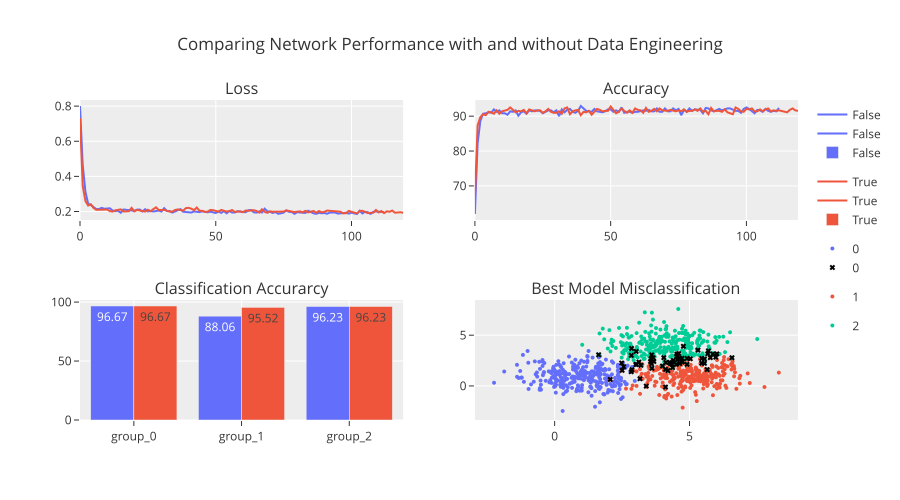

In [366]:
# plot the data
from plotly.subplots import make_subplots
fig =  make_subplots(rows=2, cols=2, subplot_titles=['Loss', 'Accuracy', 'Classification Accurarcy', 'Best Model Misclassification'],)

fig1 = px.line(data_frame=all_results, x='epoch', y='train_loss', color='extraFeature',)
fig2 = px.line(data_frame=all_results, x='epoch', y='train_acc', color='extraFeature',)
fig3 = px.bar(data_frame=all_acc_long, x='classification_groups', y='overall_accuracy', color='extra_feature', text_auto='.2f')

for trace in fig1.data:
    fig.add_trace(trace, row=1 , col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1 , col=2)

for trace in fig3.data:
    fig.add_trace(trace, row=2 , col=1)

for trace in fig4a.data:
    fig.add_trace(trace, row=2, col=2)

fig.update_layout(template='ggplot2', width=900, height=500, title='Comparing Network Performance with and without Data Engineering')

fig.show(renderer='svg');

Interpretation:
* In this experiment, I investigated whether feature engineering (adding Euclidean distance) could improve neural network performance on a 3-class classification task. While both models achieved similarly high accuracy (~95-97%), the feature-engineered model demonstrated faster convergence, reaching optimal performance in ~153 epochs compared to the baseline model requiring more training time.
    * group 1 classification appears to be marginally better than without engineering
* The limited performance improvement suggests that the original 2D features were already sufficient for this well-separated cluster dataset. However, the computational efficiency gain from faster convergence represents a practical benefit of feature engineering - achieving the same performance with less training time.
* overall conclusion: This demonstrates that feature engineering value isn't always about peak performance, but can also provide efficiency benefits and more stable optimization paths.
